In [18]:
#install.packages("devtools")
#devtools::install_github("IRkernel/IRkernel")
#IRkernel::installspec()

In [19]:
#install.packages("corrplot")
#install.packages("texreg")
#install.packages("ggeffects")
#install.packages("plm")
#install.packages("multiwayvcov")

In [20]:
library(readr)
options(readr.num_columns = 0)
library(corrplot)
library(dplyr)
library(broom)
library(ggplot2)
library(tidyr)
library(texreg)
library(ggeffects)
library(plm)
library(lmtest)
library(multiwayvcov)

options(jupyter.plot_scale=1)
set.seed(42)

In [21]:
# Load productvitity and network data
data <- read_csv('Reproducibility_Data.csv')

Rows: 1427 Columns: 21
── Column specification ────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): project_name, primary_language
dbl (19): window_starts, window_ends, Events, NLOC, LevD, Tokens, CycC, Func...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [22]:
# Filter subject projects
subject_names <- c("ansible__ansible__2020-06-11_06-06-22", 
                   "eclipse__birt__2020-06-11_00-34-50",
                   "python__cpython__2020-06-11_06-27-42",
                   "Netflix__conductor__2020-06-11_06-17-51",
                   "apache__flink__2020-06-11_13-39-22",
                   "GNOME__gtk__2020-06-13_12-30-17",
                   "Homebrew__homebrew-cask__2020-06-13_00-14-26",
                   "netxms__netxms__2020-06-11_20-06-02",
                   "sofa-framework__sofa__2020-06-13_15-35-15",
                   "VcDevel__Vc__2020-06-13_11-59-17")
data <- data %>% filter(project_name %in% subject_names)

In [23]:
data <- write_csv(data, 'Reproducibility_Data_reduced.csv')

In [24]:
data <- subset(data, select=c("Functions", "Commits", "HalEff", "TS", "N", "InD", "FModR"))

# Filter all observations with missing data
data <- data %>%
    filter_if(~is.numeric(.), all_vars(!is.na(.)))  %>%
        filter_if(~is.numeric(.), all_vars(!is.infinite(.)))  %>%
            filter_if(~is.numeric(.), all_vars(. != 0))

# Drop project name and language columns
#data <- subset(data, select=-c(`project_name`, `primary_language`, `window_starts`, `window_ends`, `E`))

# Transform variables
data$Commits <- log(data$Commits)
#data$Events <- log(data$Events)
#data$LevD <- log(data$LevD)
#data$CycC <- log(data$CycC)
#data$NLOC <- log(data$NLOC)
#data$Tokens <- log(data$Tokens)
data$Functions <- log(data$Functions)
data$HalEff <- log(data$HalEff)

data$TS <- log(data$TS)
data$N <- log(data$N)
#data$Dens <- log(data$Dens)
data$InD <- log(data$InD)
#data$EigG <- sqrt(data$EigG)

In [25]:
data

Functions,Commits,HalEff,TS,N,InD,FModR
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1.908170,2.393396,14.46378,4.394449,4.477337,1.0198314,0.3752163
1.173895,1.537796,13.04706,5.087596,5.252273,0.7087319,0.3802377
1.676405,1.572176,13.34706,5.549076,5.866468,0.4965600,0.3064297
1.508064,1.647590,13.14022,6.416732,6.565265,0.3874637,0.3202673
1.573581,1.751926,13.16120,6.481577,6.857514,0.5171150,0.3583707
2.136982,1.678413,13.69168,6.613384,7.135687,0.8172794,0.4094844
2.131756,1.605628,13.47553,6.670766,7.315218,0.8009000,0.3374308
1.996607,1.480323,13.53021,6.827629,7.304516,0.6442225,0.3310333
2.405016,1.621389,14.13468,6.762730,7.372746,0.6468664,0.3306333


ERROR: Error in corrRect(c(8, 4, 3, 1)): List 'corrRes' must be inputted!


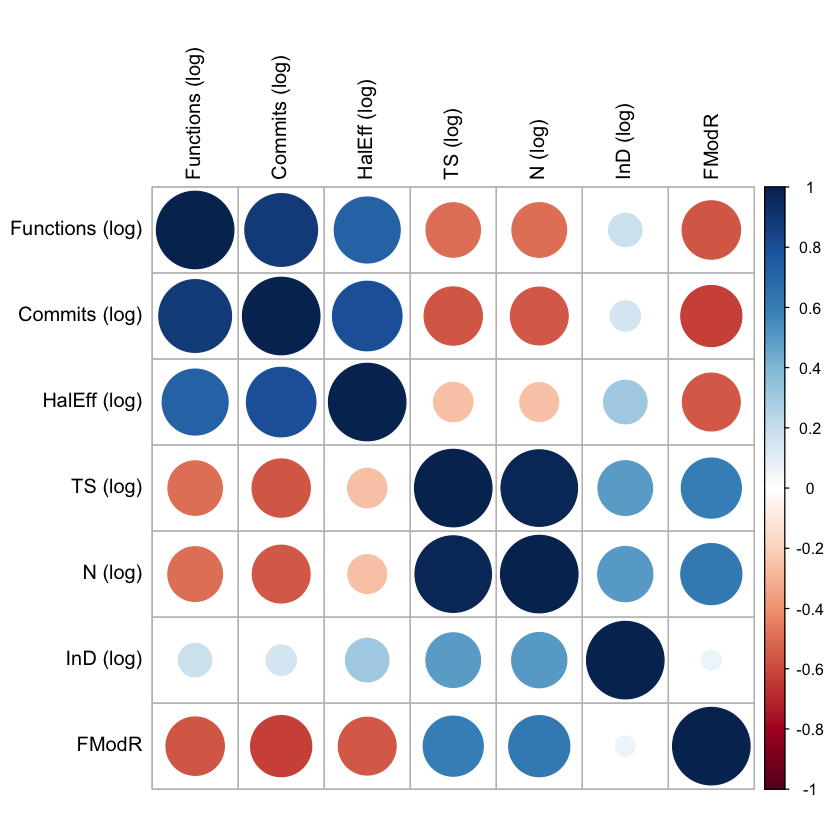

In [26]:
# Compute correlations between the transformed variables
corr <- cor(data, method="pearson")

transformed_variable_names = c(#'Events (log)',
                               #'NLOC (log)',
                               #'LevD (log)',
                               #'Tokens (log)',
                               #'CycC (log)',
                               'Functions (log)',
                               'Commits (log)',
                               'HalEff (log)',
                               'TS (log)',
                               'N (log)',
                               #'Diam',
                               #'Dens (log)',
                               #'ClustC',
                               'InD (log)',
                               #'EigG (sqrt)',
                               'FModR')

rownames(corr) <- transformed_variable_names
colnames(corr) <- transformed_variable_names

# Plot results
corrplot(corr, tl.col = "black")
corrRect(c(8,4,3,1))

In [27]:
corr

,Functions (log),Commits (log),HalEff (log),TS (log),N (log),InD (log),FModR
Functions (log),1.0000000,0.8819777,0.7252084,-0.4938211,-0.4983585,0.18616654,-0.56793167
Commits (log),0.8819777,1.0000000,0.8060012,-0.5656221,-0.5570511,0.15396094,-0.62210470
HalEff (log),0.7252084,0.8060012,1.0000000,-0.2579171,-0.2507053,0.31553287,-0.55659505
TS (log),-0.4938211,-0.5656221,-0.2579171,1.0000000,0.9751404,0.49778577,0.60147376
N (log),-0.4983585,-0.5570511,-0.2507053,0.9751404,1.0000000,0.50749728,0.62191931
InD (log),0.1861665,0.1539609,0.3155329,0.4977858,0.5074973,1.00000000,0.06717888
FModR,-0.5679317,-0.6221047,-0.5565950,0.6014738,0.6219193,0.06717888,1.00000000


In [28]:
# Run regression of productivity against teamsize
f1a = 'Commits ~ TS'
#f2a = 'Events ~ TS'
#f3a = 'LevD ~ TS'
#f4a = 'CycC ~ TS'
#f5a = 'NLOC ~ TS'
#f6a = 'Tokens ~ TS'
f7a = 'Functions ~ TS'
f8a = 'HalEff ~ TS'

fit1a <- lm(formula=f1a, data=data)
#fit2a <- lm(formula=f2a, data=data)
#fit3a <- lm(formula=f3a, data=data)
#fit4a <- lm(formula=f4a, data=data)
#fit5a <- lm(formula=f5a, data=data)
#fit6a <- lm(formula=f6a, data=data)
fit7a <- lm(formula=f7a, data=data)
fit8a <- lm(formula=f8a, data=data)

#print(screenreg(list(fit1a, fit2a, fit3a, fit4a, fit5a, fit6a, fit7a, fit8a),
#               custom.model.names = c('Commits', 'Events', 'LevD', 'CycC', 'NLOC', 'Tokens', 'Functions', 'HalEff')))

print(screenreg(list(fit1a, fit7a, fit8a),
               custom.model.names = c('Commits', 'Functions', 'HalEff')))

# We note that Bonferroni correction was applied manually to the p-values resulting from the regressions.
# Consequently, the significance level reported in our article might be lower than the ones reported here.


             Commits     Functions   HalEff    
-----------------------------------------------
(Intercept)    4.84 ***    5.53 ***   17.48 ***
              (0.19)      (0.27)      (0.38)   
TS            -0.45 ***   -0.52 ***   -0.35 ** 
              (0.05)      (0.07)      (0.11)   
-----------------------------------------------
R^2            0.32        0.24        0.07    
Adj. R^2       0.32        0.24        0.06    
Num. obs.    156         156         156       
*** p < 0.001; ** p < 0.01; * p < 0.05


In [29]:
# Run regression of productivity against teamsize and teamsize squared
f1b = 'Commits ~ TS + I(TS^2)'
#f2b = 'Events ~ TS + I(TS^2)'
#f3b = 'LevD ~ TS+I(TS^2)'
#f4b = 'CycC ~ TS + I(TS^2)'
#f5b = 'NLOC ~ TS + I(TS^2)'
#f6b = 'Tokens ~ TS + I(TS^2)'
f7b = 'Functions ~ TS + I(TS^2)'
f8b = 'HalEff ~ TS + I(TS^2)'

fit1b <- lm(formula=f1b, data=data)
#fit2b <- lm(formula=f2b, data=data)
#fit3b <- lm(formula=f3b, data=data)
#fit4b <- lm(formula=f4b, data=data)
#fit5b <- lm(formula=f5b, data=data)
#fit6b <- lm(formula=f6b, data=data)
fit7b <- lm(formula=f7b, data=data)
fit8b <- lm(formula=f8b, data=data)

#print(screenreg(list(fit1b, fit2b, fit3b, fit4b, fit5b, fit6b, fit7b, fit8b),
#      custom.model.names = c('Commits', 'Events', 'LevD', 'CycC', 'NLOC', 'Tokens', 'Functions', 'HalEff')))

print(screenreg(list(fit1b, fit7b, fit8b),
      custom.model.names = c('Commits', 'Functions', 'HalEff')))

# We note that Bonferroni correction was applied manually to the p-values resulting from the regressions.
# Consequently, the significance level reported in our article might be lower than the ones reported here.


             Commits     Functions   HalEff    
-----------------------------------------------
(Intercept)    4.64 ***    5.69 ***   16.87 ***
              (0.32)      (0.45)      (0.64)   
TS            -0.30       -0.64 *      0.09    
              (0.20)      (0.28)      (0.39)   
TS^2          -0.02        0.02       -0.07    
              (0.03)      (0.04)      (0.06)   
-----------------------------------------------
R^2            0.32        0.24        0.07    
Adj. R^2       0.31        0.23        0.06    
Num. obs.    156         156         156       
*** p < 0.001; ** p < 0.01; * p < 0.05


In [30]:
# Run regression of productivity against teamsize, with controls
f1c = 'Commits ~ TS + InD + FModR'
#f2c = 'Events ~ TS + InD + FModR'
#f3c = 'LevD ~ TS + InD + FModR'
#f4c = 'CycC ~ TS + InD + FModR'
#f5c = 'NLOC ~ TS + InD + FModR'
#f6c = 'Tokens ~ TS + InD + FModR'
f7c = 'Functions ~ TS + InD + FModR'
f8c = 'HalEff ~ TS + InD + FModR'

fit1c <- lm(formula=f1c, data=data)
#fit2c <- lm(formula=f2c, data=data)
#fit3c <- lm(formula=f3c, data=data)
#fit4c <- lm(formula=f4c, data=data)
#fit5c <- lm(formula=f5c, data=data)
#fit6c <- lm(formula=f6c, data=data)
fit7c <- lm(formula=f7c, data=data)
fit8c <- lm(formula=f8c, data=data)

#print(screenreg(list(fit1c, fit2c, fit3c, fit4c, fit5c, fit6c, fit7c, fit8c),
#      custom.model.names = c('Commits', 'Events', 'LevD', 'CycC', 'NLOC', 'Tokens', 'Functions', 'HalEff')))

print(screenreg(list(fit1c, fit7c, fit8c),
      custom.model.names = c('Commits', 'Functions', 'HalEff')))

# We note that Bonferroni correction was applied manually to the p-values resulting from the regressions.
# Consequently, the significance level reported in our article might be lower than the ones reported here.


             Commits     Functions   HalEff    
-----------------------------------------------
(Intercept)    4.80 ***    5.45 ***   17.65 ***
              (0.15)      (0.23)      (0.31)   
TS            -0.52 ***   -0.63 ***   -0.27 *  
              (0.06)      (0.09)      (0.12)   
InD            0.86 ***    1.15 ***    1.31 ***
              (0.11)      (0.16)      (0.22)   
FModR         -2.91 ***   -3.64 **    -8.92 ***
              (0.75)      (1.11)      (1.53)   
-----------------------------------------------
R^2            0.61        0.53        0.45    
Adj. R^2       0.60        0.52        0.44    
Num. obs.    156         156         156       
*** p < 0.001; ** p < 0.01; * p < 0.05


In [31]:
# Run regression of productivity against teamsize and teamsize squared, with controls
f1d = 'Commits ~ TS + I(TS^2) + InD + FModR'
#f2d = 'Events ~ TS + I(TS^2) + InD + FModR'
#f3d = 'LevD ~ TS + I(TS^2) + InD + FModR'
#f4d = 'CycC ~ TS + I(TS^2) + InD + FModR'
#f5d = 'NLOC ~ TS + I(TS^2) + InD + FModR'
#f6d = 'Tokens ~ TS + I(TS^2) + InD + FModR'
f7d = 'Functions ~ TS + I(TS^2) + InD + FModR'
f8d = 'HalEff ~ TS + I(TS^2) + InD + FModR'

fit1d <- lm(formula=f1d, data=data)
#fit2d <- lm(formula=f2d, data=data)
#fit3d <- lm(formula=f3d, data=data)
#fit4d <- lm(formula=f4d, data=data)
#fit5d <- lm(formula=f5d, data=data)
#fit6d <- lm(formula=f6d, data=data)
fit7d <- lm(formula=f7d, data=data)
fit8d <- lm(formula=f8d, data=data)

#print(screenreg(list(fit1d, fit2d, fit3d, fit4d, fit5d, fit6d, fit7d, fit8d),
#      custom.model.names = c('Commits', 'Events', 'LevD', 'CycC', 'NLOC', 'Tokens', 'Functions', 'HalEff')))

print(screenreg(list(fit1d, fit7d, fit8d),
      custom.model.names = c('Commits', 'Functions', 'HalEff')))

# We note that Bonferroni correction was applied manually to the p-values resulting from the regressions.
# Consequently, the significance level reported in our article might be lower than the ones reported here.


             Commits     Functions   HalEff    
-----------------------------------------------
(Intercept)    6.11 ***    7.87 ***   19.18 ***
              (0.25)      (0.33)      (0.54)   
TS            -1.77 ***   -2.93 ***   -1.73 ***
              (0.20)      (0.28)      (0.45)   
TS^2           0.16 ***    0.29 ***    0.19 ***
              (0.02)      (0.03)      (0.05)   
InD            1.38 ***    2.12 ***    1.93 ***
              (0.13)      (0.17)      (0.28)   
FModR         -1.69 *     -1.38       -7.49 ***
              (0.70)      (0.95)      (1.53)   
-----------------------------------------------
R^2            0.69        0.68        0.49    
Adj. R^2       0.69        0.67        0.48    
Num. obs.    156         156         156       
*** p < 0.001; ** p < 0.01; * p < 0.05


In [32]:
# Run regression of productivity against teamsize and teamsize squared, with controls and interactions
f1e = 'Commits ~ TS + InD + TS*InD + FModR'
#f2e = 'Events ~ TS + InD + TS*InD + FModR'
#f3e = 'LevD ~ TS + InD  +TS*InD + FModR'
#f4e = 'CycC ~ TS + InD  + TS*InD + FModR'
#f5e = 'NLOC ~ TS + InD  + TS*InD + FModR'
#f6e = 'Tokens ~ TS + InD  + TS*InD + FModR'
f7e = 'Functions ~ TS + InD + TS*InD + FModR'
f8e = 'HalEff ~ TS + InD  +TS*InD + FModR'

fit1e <- lm(formula=f1e, data=data)
#fit2e <- lm(formula=f2e, data=data)
#fit3e <- lm(formula=f3e, data=data)
#fit4e <- lm(formula=f4e, data=data)
#fit5e <- lm(formula=f5e, data=data)
#fit6e <- lm(formula=f6e, data=data)
fit7e <- lm(formula=f7e, data=data)
fit8e <- lm(formula=f8e, data=data)

#print(screenreg(list(fit1e, fit2e, fit3e, fit4e, fit5e, fit6e, fit7e, fit8e),
#      custom.model.names = c('Commits', 'Events', 'LevD', 'CycC', 'NLOC', 'Tokens', 'Functions', 'HalEff')))

print(screenreg(list(fit1e, fit7e, fit8e),
      custom.model.names = c('Commits', 'Functions', 'HalEff')))

# We note that Bonferroni correction was applied manually to the p-values resulting from the regressions.
# Consequently, the significance level reported in our article might be lower than the ones reported here.


             Commits     Functions   HalEff    
-----------------------------------------------
(Intercept)    4.65 ***    5.29 ***   17.48 ***
              (0.18)      (0.27)      (0.37)   
TS            -0.43 ***   -0.54 ***   -0.17    
              (0.08)      (0.13)      (0.17)   
InD            1.23 ***    1.56 ***    1.73 ** 
              (0.28)      (0.41)      (0.56)   
FModR         -3.09 ***   -3.84 ***   -9.12 ***
              (0.76)      (1.13)      (1.55)   
TS:InD        -0.13       -0.14       -0.14    
              (0.09)      (0.13)      (0.17)   
-----------------------------------------------
R^2            0.62        0.53        0.45    
Adj. R^2       0.61        0.52        0.44    
Num. obs.    156         156         156       
*** p < 0.001; ** p < 0.01; * p < 0.05


In [33]:
#linear_formula <- 'y ~ x'
#quadratic_formula <- 'y ~ x + I(x^2)'

#ggplot(data, aes(x=exp(TS), y=exp(CycC))) + 
#    geom_point(size  = 3,
#               stroke = 0,
#               shape=19,
#               alpha = .15)+
#    stat_smooth(method = "lm", formula = linear_formula, size = 1, color = 'green')+
#    stat_smooth(method = "lm", formula = quadratic_formula, size = 1, color = 'yellow') +
#    annotation_logticks()+
#    scale_x_log10()+
#    scale_y_log10()+
#    xlab("Team Size") +
#    ylab("CycC / Team Member")

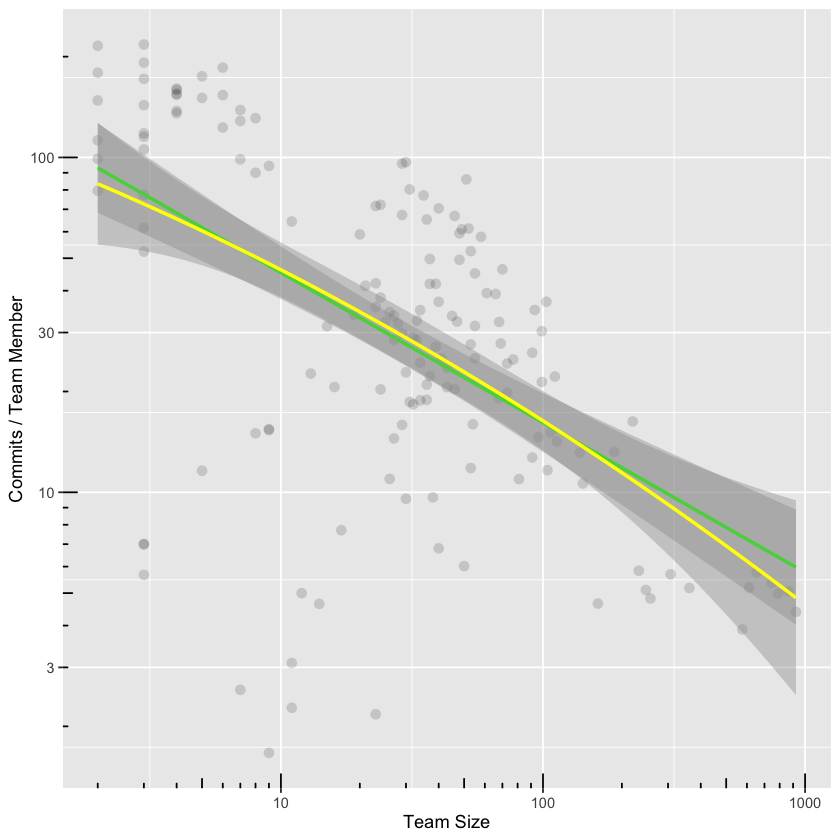

In [34]:
# Replication: commits
linear_formula <- 'y ~ x'
quadratic_formula <- 'y ~ x + I(x^2)'

ggplot(data, aes(x=exp(TS), y=exp(Commits))) + 
    geom_point(size  = 3,
               stroke = 0,
               shape=19,
               alpha = .15)+
    stat_smooth(method = "lm", formula = linear_formula, size = 1, color = 'green')+
    stat_smooth(method = "lm", formula = quadratic_formula, size = 1, color = 'yellow') +
    annotation_logticks()+
    scale_x_log10()+
    scale_y_log10()+
    xlab("Team Size") +
    ylab("Commits / Team Member")

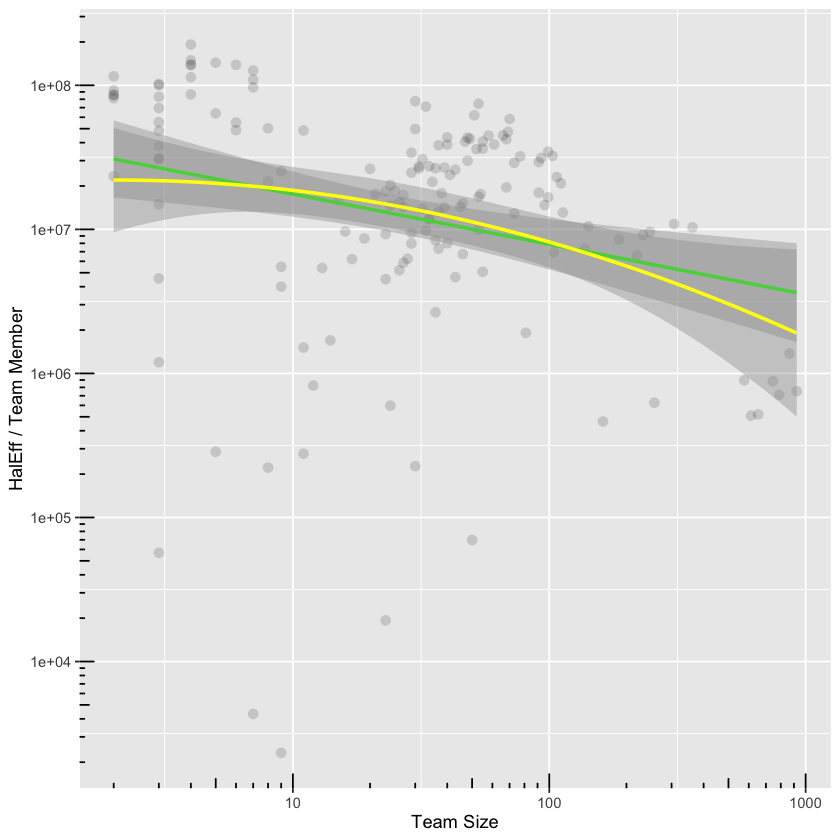

In [35]:
# Replication: Halstead effort
linear_formula <- 'y ~ x'
quadratic_formula <- 'y ~ x + I(x^2)'

ggplot(data, aes(x=exp(TS), y=exp(HalEff))) + 
    geom_point(size  = 3,
               stroke = 0,
               shape=19,
               alpha = .15)+
    stat_smooth(method = "lm", formula = linear_formula, size = 1, color = 'green')+
    stat_smooth(method = "lm", formula = quadratic_formula, size = 1, color = 'yellow') +
    annotation_logticks()+
    scale_x_log10()+
    scale_y_log10()+
    xlab("Team Size") +
    ylab("HalEff / Team Member")

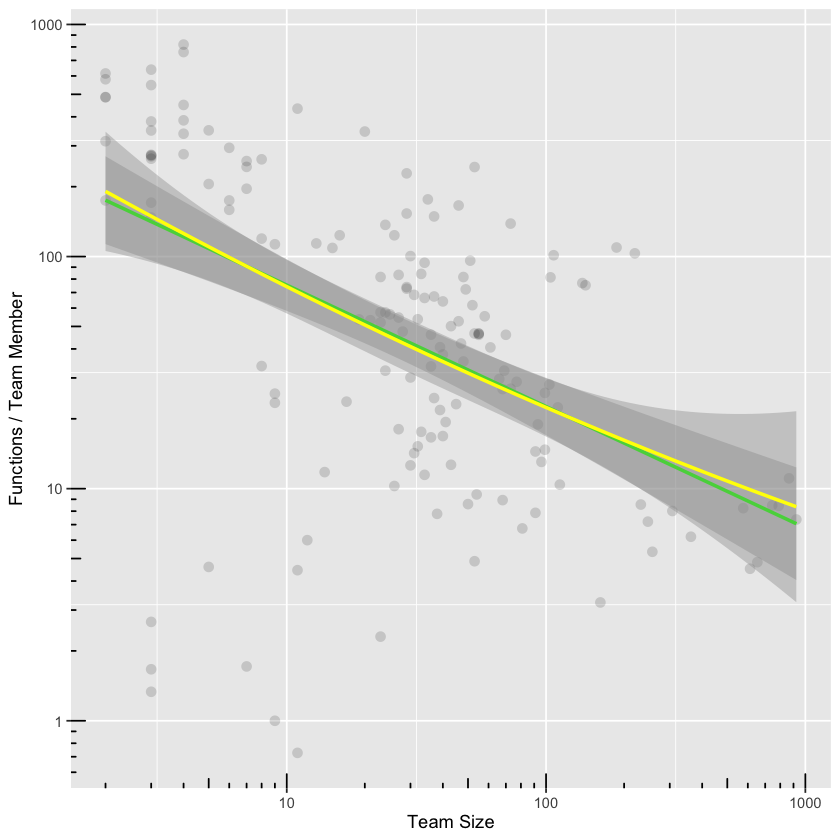

In [36]:
# Replication: functions
linear_formula <- 'y ~ x'
quadratic_formula <- 'y ~ x + I(x^2)'

ggplot(data, aes(x=exp(TS), y=exp(Functions))) + 
    geom_point(size  = 3,
               stroke = 0,
               shape=19,
               alpha = .15)+
    stat_smooth(method = "lm", formula = linear_formula, size = 1, color = 'green')+
    stat_smooth(method = "lm", formula = quadratic_formula, size = 1, color = 'yellow') +
    annotation_logticks()+
    scale_x_log10()+
    scale_y_log10()+
    xlab("Team Size") +
    ylab("Functions / Team Member")

In [37]:
#dtfit5e <- ggpredict(fit5e,  terms = c("TS [all]", "InD [-.7, 0, .7, 1.6, 2.3]"))

#ggplot(dtfit5e, aes(exp(x), exp(predicted), color = group)) +
#    scale_x_log10() +
#    scale_y_log10() +
#    geom_point() +
#    geom_errorbar(aes(ymin = exp(conf.low), ymax = exp(conf.high)))+
#    xlab("Team Size") +
#    ylab("NLOC / Team Member") + annotation_logticks()  +
#    scale_color_manual("Mean Indegree", labels = c("0.5", "1", "2", "5", "10"),
#                       values = c('red', 'green', 'blue', 'cyan', 'magenta'))

In [38]:
## Load productvitity and network data
#data <- read_csv('Reproducibility_Data.csv', show_col_types = FALSE)

## Filter all observations with missing data
#data <- data %>%
#    filter_if(~is.numeric(.), all_vars(!is.na(.)))  %>%
#        filter_if(~is.numeric(.), all_vars(!is.infinite(.)))  %>%
#            filter_if(~is.numeric(.), all_vars(. != 0))

## Drop project name and language columns
#data <- subset(data, select=-c(`project_name`, `primary_language`))

#data <- data %>%
#              mutate(TS_stratum = case_when(
#                  2 <= TS  & TS <= 4 ~ "2-4",
#                  5 <= TS  & TS <= 8 ~ "5-8",
#                  9 <= TS  & TS <= 15 ~ "9-15",
#                  16 <= TS  & TS <= 30 ~ "16-30",
#                  31 <= TS  & TS <= 58 ~ "31-58",
#                  59 <= TS  & TS <= 115 ~ "59-115",
#                  116 <= TS  & TS <= 226 ~ "116-226",
#                  227 <= TS  & TS <= 443 ~ "227-443",
#                  444 <= TS  & TS <= 871 ~ "444-871",
#                  872 <= TS  & TS <= 1711 ~ "872-1711"
#                ))

#data$TS_stratum = factor(data$TS_stratum, levels = c("2-4", "5-8", "9-15", "16-30", "31-58", "59-115",
#                                                     "116-226", "227-443", "444-871", "872-1711"),
#                         ordered = TRUE)


#ggplot(aes(y = InD, x = TS_stratum), data = data) + geom_boxplot() +
#    theme(axis.text.x = element_text(angle = 30, hjust = 1)) + xlab("Team Size")